# TRAUMALOS — Régression logistique calibrée avec bootstrap pour DDS_Réa ≥ 19 jours

Ce notebook est une version simplifiée et orientée **déploiement Streamlit** des notebooks initiaux.

Objectif :
1. utiliser uniquement une **régression logistique** ;
2. conserver les huit prédicteurs sélectionnés dans les notebooks sources ;
3. optimiser la régression logistique exclusivement sur le jeu de développement ;
4. recalibrer les probabilités par **calibration sigmoïde de Platt** avec validation croisée ;
5. construire des **intervalles de confiance bootstrap à 95 % pour les probabilités individuelles prédites** ;
6. évaluer le modèle final sur le jeu de test resté intact ;
7. sauvegarder un bundle `joblib` contenant le modèle final calibré, les modèles bootstrap et le schéma d'entrée nécessaire à une future interface Streamlit.

Aucun composant Google Colab n'est utilisé. Le notebook peut être ouvert et exécuté directement dans **VS Code + extension Jupyter**.

## 1. Environnement

Installation recommandée dans le terminal de VS Code :

```bash
python -m venv .venv
# Windows
.venv\Scripts\activate
# Linux/macOS
# source .venv/bin/activate

pip install -r requirements_traumalos_logistic.txt
```

Le bootstrap recalibre un modèle sur chaque échantillon bootstrap. `N_BOOTSTRAP=500` est adapté à l'analyse finale mais peut être réduit à 50–100 pendant les tests de code.

In [1]:
from pathlib import Path
import json
import platform
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import sklearn

from scipy.stats import loguniform
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
OUTCOME_KEY = "DDS_rea"
OUTCOME_LABEL = "Prolonged ICU LOS"
OUTCOME_THRESHOLD = 19
OUTCOME_OPERATOR = ">="

# ---------------------------
# Chemins VS Code / locaux
# ---------------------------
PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "model_outputs_DDS_rea_logistic"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_BUNDLE_PATH = OUTPUT_DIR / "traumalos_dds_rea_logistic_bundle.joblib"

# ---------------------------
# Bootstrap
# ---------------------------
N_BOOTSTRAP = 500
CI_LEVEL = 0.95
BOOTSTRAP_RANDOM_STATE = 2026

# Pendant le développement rapide, vous pouvez utiliser par exemple :
# N_BOOTSTRAP = 50

print("Python       :", platform.python_version())
print("pandas       :", pd.__version__)
print("numpy        :", np.__version__)
print("scipy        :", scipy.__version__)
print("scikit-learn :", sklearn.__version__)
print("Dossier data :", DATA_DIR.resolve())
print("Sorties      :", OUTPUT_DIR.resolve())

Python       : 3.14.4
pandas       : 3.0.6
numpy        : 2.5.3
scipy        : 1.18.1
scikit-learn : 1.9.1
Dossier data : C:\Users\h.lekehal\Downloads\TRAUMALOS\data
Sorties      : C:\Users\h.lekehal\Downloads\TRAUMALOS\model_outputs_DDS_rea_logistic


## 2. Chargement des données

In [2]:
# ============================================================
# CHARGEMENT DES DONNÉES — DDS_Réa
# ============================================================
# Structure attendue :
#   data/
#   ├── X_train_DDS_Rea_imputed.xlsx
#   └── X_test_DDS_Rea_imputed.xlsx
#
# Chaque fichier contient les prédicteurs ET la colonne DDS_rea_num.
#
# Si vos fichiers se trouvent ailleurs, modifiez uniquement DATA_DIR.

TRAIN_FILE = DATA_DIR / "X_train_DDS_Rea_imputed.xlsx"
TEST_FILE  = DATA_DIR / "X_test_DDS_Rea_imputed.xlsx"

for p in [TRAIN_FILE, TEST_FILE]:
    if not p.exists():
        raise FileNotFoundError(
            f"Fichier introuvable : {p}\n"
            "Modifiez DATA_DIR dans la cellule de configuration."
        )

dtrain = pd.read_excel(TRAIN_FILE)
dtest = pd.read_excel(TEST_FILE)

TARGET_COLUMN = "DDS_rea_num"

X_train = dtrain.drop(columns=[TARGET_COLUMN]).copy()
X_test  = dtest.drop(columns=[TARGET_COLUMN]).copy()

y_train_continuous = dtrain[TARGET_COLUMN].copy()
y_test_continuous  = dtest[TARGET_COLUMN].copy()

# Le notebook source utilisait >= 19 ; cette définition est conservée.
y_train = (y_train_continuous >= OUTCOME_THRESHOLD).astype(int)
y_test  = (y_test_continuous >= OUTCOME_THRESHOLD).astype(int)

print("Train :", X_train.shape, "| Test :", X_test.shape)
print("Prévalence train :", f"{y_train.mean():.3%}")
print("Prévalence test  :", f"{y_test.mean():.3%}")

Train : (21343, 65) | Test : (5336, 65)
Prévalence train : 10.411%
Prévalence test  : 10.682%


## 3. Sélection des huit prédicteurs et contrôle des données

In [5]:
FEATURES = [
    "ISS score",
    "CGS score",
    "Trauma center",
    "SAPS II",
    "AIS head neck",
    "AIS chest",
    "hemorragic shock",
    "Surgical and/or hemostatic radiological procedures within first 24 hours"
]

# Variables catégorielles à encoder en One-Hot
CATEGORICAL_COLS = [
    "Trauma center",
    "Surgical and/or hemostatic radiological procedures within first 24 hours"
]

# Variable binaire : No = 0, Yes = 1
BINARY_COLS = [
    "hemorragic shock"
]

# Variables numériques à standardiser
NUMERIC_COLS = [
    c for c in FEATURES
    if c not in CATEGORICAL_COLS + BINARY_COLS
]


# ============================================================
# Vérification de la présence des variables
# ============================================================

missing_train = [c for c in FEATURES if c not in X_train.columns]
missing_test = [c for c in FEATURES if c not in X_test.columns]

if missing_train or missing_test:
    raise KeyError(
        f"Variables manquantes. Train={missing_train} | Test={missing_test}"
    )


# ============================================================
# Sélection des variables
# ============================================================

X_train = X_train[FEATURES].copy().reset_index(drop=True)
X_test = X_test[FEATURES].copy().reset_index(drop=True)

y_train = pd.Series(y_train).astype(int).reset_index(drop=True)
y_test = pd.Series(y_test).astype(int).reset_index(drop=True)


# ============================================================
# Codage de la variable binaire hemorragic shock
# ============================================================

def encode_binary_yes_no(series):
    """
    Convertit Yes/No en 1/0 de manière robuste.
    """
    mapping = {
        "yes": 1,
        "no": 0
    }

    normalized = (
        series
        .astype("string")
        .str.strip()
        .str.lower()
    )

    encoded = normalized.map(mapping)

    # Vérifier s'il existe des modalités inattendues
    unexpected = normalized[
        normalized.notna() & ~normalized.isin(mapping.keys())
    ].unique()

    if len(unexpected) > 0:
        raise ValueError(
            f"Modalités inattendues dans 'hemorragic shock' : {unexpected}"
        )

    return encoded.astype("Int64")


X_train["hemorragic shock"] = encode_binary_yes_no(
    X_train["hemorragic shock"]
)

X_test["hemorragic shock"] = encode_binary_yes_no(
    X_test["hemorragic shock"]
)


# ============================================================
# Type des variables catégorielles
# ============================================================

for col in CATEGORICAL_COLS:
    X_train[col] = X_train[col].astype("object")
    X_test[col] = X_test[col].astype("object")


# ============================================================
# Contrôles
# ============================================================

print("Variables numériques :", NUMERIC_COLS)
print("Variables binaires :", BINARY_COLS)
print("Variables catégorielles :", CATEGORICAL_COLS)

print("\nDistribution de 'hemorragic shock' dans le train :")
print(X_train["hemorragic shock"].value_counts(dropna=False))

print("\nDistribution de 'hemorragic shock' dans le test :")
print(X_test["hemorragic shock"].value_counts(dropna=False))


# ============================================================
# Distribution des classes outcome
# ============================================================

class_summary = pd.DataFrame({
    "train_n": y_train.value_counts().sort_index(),
    "train_pct": 100 * y_train.value_counts(normalize=True).sort_index(),
    "test_n": y_test.value_counts().sort_index(),
    "test_pct": 100 * y_test.value_counts(normalize=True).sort_index(),
})

class_summary.index.name = "class"

display(class_summary.round(2))


# ============================================================
# Valeurs manquantes
# ============================================================

print("\nValeurs manquantes dans X_train :")
display(X_train.isna().sum().to_frame("n_missing"))

Variables numériques : ['ISS score', 'CGS score', 'SAPS II', 'AIS head neck', 'AIS chest']
Variables binaires : ['hemorragic shock']
Variables catégorielles : ['Trauma center', 'Surgical and/or hemostatic radiological procedures within first 24 hours']

Distribution de 'hemorragic shock' dans le train :
hemorragic shock
0    18326
1     3017
Name: count, dtype: Int64

Distribution de 'hemorragic shock' dans le test :
hemorragic shock
0    4593
1     743
Name: count, dtype: Int64


,train_n,train_pct,test_n,test_pct
class,,,,
0,19121,89.59,4766,89.32
1,2222,10.41,570,10.68



Valeurs manquantes dans X_train :


,n_missing
ISS score,0
CGS score,0
Trauma center,0
SAPS II,0
AIS head neck,0
AIS chest,0
hemorragic shock,0
Surgical and/or hemostatic radiological procedures within first 24 hours,0


## 4. Pipeline de prétraitement + régression logistique

Les variables numériques sont standardisées. Les deux variables catégorielles sont encodées par one-hot encoding avec `handle_unknown="ignore"` afin que l'application puisse recevoir une modalité non vue sans planter.

La classe positive est pondérée automatiquement via `class_weight="balanced"`, comme dans le notebook source. La recherche d'hyperparamètres porte uniquement sur la régression logistique et n'utilise jamais le jeu de test.

In [6]:
# ============================================================
# PREPROCESSING
# ============================================================

def make_one_hot_encoder():
    """
    Compatibilité entre versions récentes et anciennes
    de scikit-learn.
    """
    try:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    except TypeError:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse=False
        )


# ------------------------------------------------------------
# 1. Variables numériques
# ------------------------------------------------------------
# Standardisation uniquement des variables numériques continues/
# ordinales.

numeric_transformer = Pipeline([
    ("scaler", StandardScaler())
])


# ------------------------------------------------------------
# 2. Variables catégorielles
# ------------------------------------------------------------
# One-Hot Encoding.

categorical_transformer = Pipeline([
    ("onehot", make_one_hot_encoder())
])


# ------------------------------------------------------------
# 3. Préprocesseur global
# ------------------------------------------------------------
#
# num    -> StandardScaler
# binary -> passthrough : garde directement 0/1
# cat    -> OneHotEncoder
#

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, NUMERIC_COLS),
        ("binary", "passthrough", BINARY_COLS),
        ("cat", categorical_transformer, CATEGORICAL_COLS),
    ],
    remainder="drop",
)


# ============================================================
# RÉGRESSION LOGISTIQUE
# ============================================================

logistic = LogisticRegression(
    solver="saga",
    class_weight="balanced",
    max_iter=5000,
    random_state=RANDOM_STATE,
)


# ============================================================
# PIPELINE COMPLET
# ============================================================

base_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", logistic),
])


# ============================================================
# VALIDATION CROISÉE
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)


# ============================================================
# ESPACE D'HYPERPARAMÈTRES
# ============================================================

param_distributions = [
    {
        "model__C": loguniform(1e-3, 1e2),
        "model__penalty": ["l1", "l2"],
    },
    {
        "model__C": loguniform(1e-3, 1e2),
        "model__penalty": ["elasticnet"],
        "model__l1_ratio": np.linspace(0.0, 1.0, 11),
    },
]


# ============================================================
# RANDOMIZED SEARCH
# ============================================================

search = RandomizedSearchCV(
    estimator=base_pipeline,
    param_distributions=param_distributions,
    n_iter=30,
    scoring="roc_auc",
    n_jobs=-1,
    cv=cv,
    random_state=RANDOM_STATE,
    refit=True,
    verbose=1,
)


# ============================================================
# ENTRAÎNEMENT
# ============================================================

search.fit(X_train, y_train)

best_base_pipeline = search.best_estimator_


# ============================================================
# RÉSULTATS
# ============================================================

print(
    "Meilleur ROC-AUC CV :",
    round(search.best_score_, 4)
)

print("\nMeilleurs hyperparamètres :")

for key, value in search.best_params_.items():
    print(f"  {key}: {value}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Meilleur ROC-AUC CV : 0.8446

Meilleurs hyperparamètres :
  model__C: 0.02539057572102413
  model__penalty: l2


## 5. Recalibration probabiliste

La calibration est effectuée **uniquement sur le jeu de développement** par validation croisée stratifiée à cinq plis. La méthode `sigmoid` correspond à une calibration de type Platt. Le jeu de test reste réservé à l'évaluation finale.

In [7]:
def make_calibrated_classifier(estimator, method="sigmoid", cv=None):
    """
    Construit CalibratedClassifierCV avec compatibilité entre versions sklearn.
    ensemble=False produit un modèle final compact après calibration hors pli.
    """
    kwargs = {
        "method": method,
        "cv": cv,
        "ensemble": False,
    }

    # Certaines versions acceptent n_jobs, d'autres peuvent différer.
    try:
        return CalibratedClassifierCV(estimator=estimator, n_jobs=1, **kwargs)
    except TypeError:
        try:
            return CalibratedClassifierCV(base_estimator=estimator, n_jobs=1, **kwargs)
        except TypeError:
            try:
                return CalibratedClassifierCV(estimator=estimator, **kwargs)
            except TypeError:
                return CalibratedClassifierCV(base_estimator=estimator, **kwargs)

calibration_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=2026,
)

final_calibrated_model = make_calibrated_classifier(
    estimator=clone(best_base_pipeline),
    method="sigmoid",
    cv=calibration_cv,
)

final_calibrated_model.fit(X_train, y_train)

proba_uncalibrated = best_base_pipeline.predict_proba(X_test)[:, 1]
proba_calibrated = final_calibrated_model.predict_proba(X_test)[:, 1]

print("Brier avant calibration :", round(brier_score_loss(y_test, proba_uncalibrated), 4))
print("Brier après calibration :", round(brier_score_loss(y_test, proba_calibrated), 4))
print("ROC-AUC avant calibration:", round(roc_auc_score(y_test, proba_uncalibrated), 4))
print("ROC-AUC après calibration:", round(roc_auc_score(y_test, proba_calibrated), 4))

Brier avant calibration : 0.1625
Brier après calibration : 0.0827
ROC-AUC avant calibration: 0.8463
ROC-AUC après calibration: 0.8463


## 6. Évaluation finale sur le jeu de test

In [8]:
DECISION_THRESHOLD = 0.50
y_pred = (proba_calibrated >= DECISION_THRESHOLD).astype(int)

metrics = {
    "roc_auc": roc_auc_score(y_test, proba_calibrated),
    "brier_score": brier_score_loss(y_test, proba_calibrated),
    "accuracy": accuracy_score(y_test, y_pred),
    "precision_class_1": precision_score(y_test, y_pred, zero_division=0),
    "recall_class_1": recall_score(y_test, y_pred, zero_division=0),
    "f1_class_1": f1_score(y_test, y_pred, zero_division=0),
}

display(pd.DataFrame([metrics]).round(4))
print(classification_report(y_test, y_pred, digits=3, zero_division=0))
print("Matrice de confusion :")
print(confusion_matrix(y_test, y_pred))

,roc_auc,brier_score,accuracy,precision_class_1,recall_class_1,f1_class_1
0,0.8463,0.0827,0.8872,0.373,0.0825,0.1351


              precision    recall  f1-score   support

           0      0.900     0.983     0.940      4766
           1      0.373     0.082     0.135       570

    accuracy                          0.887      5336
   macro avg      0.636     0.533     0.537      5336
weighted avg      0.843     0.887     0.854      5336

Matrice de confusion :
[[4687   79]
 [ 523   47]]


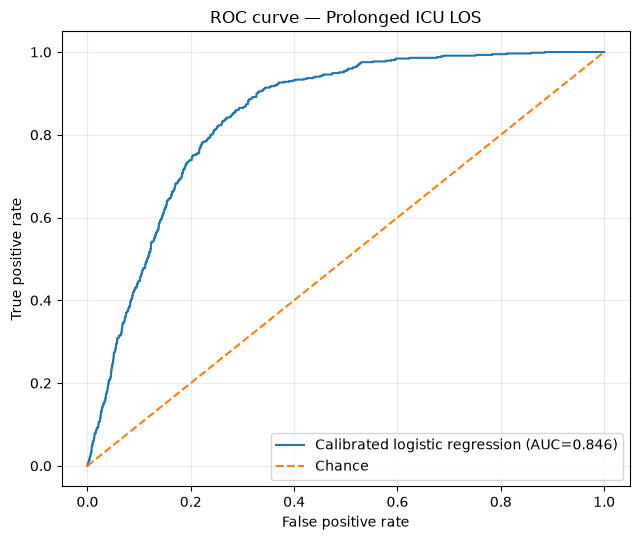

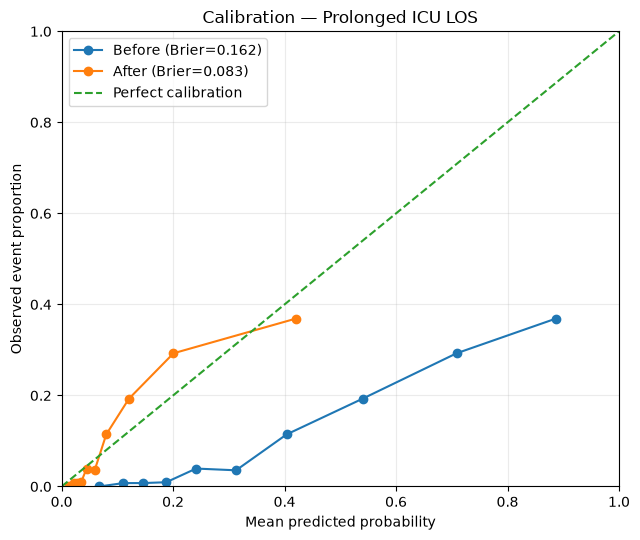

In [9]:
# Courbe ROC
fpr, tpr, _ = roc_curve(y_test, proba_calibrated)
auc = roc_auc_score(y_test, proba_calibrated)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.plot(fpr, tpr, label=f"Calibrated logistic regression (AUC={auc:.3f})")
ax.plot([0, 1], [0, 1], "--", label="Chance")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title(f"ROC curve — {OUTCOME_LABEL}")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

# Calibration avant/après
frac_before, mean_before = calibration_curve(
    y_test, proba_uncalibrated, n_bins=10, strategy="quantile"
)
frac_after, mean_after = calibration_curve(
    y_test, proba_calibrated, n_bins=10, strategy="quantile"
)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.plot(mean_before, frac_before, marker="o",
        label=f"Before (Brier={brier_score_loss(y_test, proba_uncalibrated):.3f})")
ax.plot(mean_after, frac_after, marker="o",
        label=f"After (Brier={brier_score_loss(y_test, proba_calibrated):.3f})")
ax.plot([0, 1], [0, 1], "--", label="Perfect calibration")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed event proportion")
ax.set_title(f"Calibration — {OUTCOME_LABEL}")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "calibration_before_after.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Bootstrap des probabilités individuelles

Principe : chaque réplication tire avec remise un échantillon de même taille dans le jeu de développement. La régression logistique utilisant les hyperparamètres déjà sélectionnés est **réentraînée puis recalibrée** sur cet échantillon. Les modèles bootstrap prédisent ensuite les mêmes patients.

Pour un patient \(i\), on obtient \(B\) probabilités calibrées \(p_i^{(1)},\dots,p_i^{(B)}\). L'IC à 95 % est l'intervalle percentile :

\[
[Q_{0.025}(p_i^{(b)}),\;Q_{0.975}(p_i^{(b)})].
\]

Cet intervalle représente l'incertitude d'estimation du modèle liée au ré-échantillonnage du jeu de développement. Il ne doit pas être interprété comme un intervalle prédictif sur la durée de séjour elle-même.

In [10]:
def draw_valid_bootstrap_indices(y, rng, min_class_count):
    """
    Tire un bootstrap contenant les deux classes et suffisamment
    d'observations par classe pour la calibration CV.
    """
    y_arr = np.asarray(y)
    n = len(y_arr)

    for _ in range(200):
        idx = rng.integers(0, n, size=n)
        counts = np.bincount(y_arr[idx], minlength=2)
        if counts.min() >= min_class_count:
            return idx

    raise RuntimeError(
        "Impossible de générer un échantillon bootstrap valide. "
        "Réduisez CALIBRATION_FOLDS si la classe positive est très rare."
    )


def fit_bootstrap_calibrated_models(
    X,
    y,
    best_pipeline,
    n_bootstrap=500,
    calibration_folds=5,
    random_state=2026,
):
    rng = np.random.default_rng(random_state)
    models = []

    for b in range(n_bootstrap):
        idx = draw_valid_bootstrap_indices(
            y=y,
            rng=rng,
            min_class_count=calibration_folds,
        )

        X_b = X.iloc[idx].reset_index(drop=True)
        y_b = y.iloc[idx].reset_index(drop=True)

        cv_b = StratifiedKFold(
            n_splits=calibration_folds,
            shuffle=True,
            random_state=random_state + b + 1,
        )

        calibrated_b = make_calibrated_classifier(
            estimator=clone(best_pipeline),
            method="sigmoid",
            cv=cv_b,
        )
        calibrated_b.fit(X_b, y_b)
        models.append(calibrated_b)

        if (b + 1) % 25 == 0 or (b + 1) == n_bootstrap:
            print(f"Bootstrap {b + 1}/{n_bootstrap}")

    return models


bootstrap_models = fit_bootstrap_calibrated_models(
    X=X_train,
    y=y_train,
    best_pipeline=best_base_pipeline,
    n_bootstrap=N_BOOTSTRAP,
    calibration_folds=5,
    random_state=BOOTSTRAP_RANDOM_STATE,
)

print("Nombre de modèles bootstrap :", len(bootstrap_models))

Bootstrap 25/500
Bootstrap 50/500
Bootstrap 75/500
Bootstrap 100/500
Bootstrap 125/500
Bootstrap 150/500
Bootstrap 175/500
Bootstrap 200/500
Bootstrap 225/500
Bootstrap 250/500
Bootstrap 275/500
Bootstrap 300/500
Bootstrap 325/500
Bootstrap 350/500
Bootstrap 375/500
Bootstrap 400/500
Bootstrap 425/500
Bootstrap 450/500
Bootstrap 475/500
Bootstrap 500/500
Nombre de modèles bootstrap : 500


In [11]:
def bootstrap_probability_interval(
    bootstrap_models,
    X,
    ci_level=0.95,
):
    """
    Retourne :
      - matrice des probabilités bootstrap [n_patients, n_bootstrap]
      - borne basse
      - borne haute
    """
    if not 0 < ci_level < 1:
        raise ValueError("ci_level doit être compris entre 0 et 1.")

    boot_matrix = np.column_stack([
        model.predict_proba(X)[:, 1]
        for model in bootstrap_models
    ])

    alpha = 1.0 - ci_level
    lower = np.quantile(boot_matrix, alpha / 2.0, axis=1)
    upper = np.quantile(boot_matrix, 1.0 - alpha / 2.0, axis=1)

    return boot_matrix, lower, upper


bootstrap_test_matrix, proba_ci_low, proba_ci_high = bootstrap_probability_interval(
    bootstrap_models=bootstrap_models,
    X=X_test,
    ci_level=CI_LEVEL,
)

test_predictions = X_test.copy()
test_predictions.insert(0, "y_true", y_test.values)
test_predictions["predicted_probability"] = proba_calibrated
test_predictions["ci_lower_95"] = proba_ci_low
test_predictions["ci_upper_95"] = proba_ci_high
test_predictions["ci_width"] = proba_ci_high - proba_ci_low
test_predictions["predicted_class_0_5"] = (
    test_predictions["predicted_probability"] >= DECISION_THRESHOLD
).astype(int)

display(
    test_predictions[
        ["y_true", "predicted_probability", "ci_lower_95", "ci_upper_95", "ci_width"]
    ].head(10).round(4)
)

test_predictions.to_csv(
    OUTPUT_DIR / "test_predictions_with_bootstrap_ci.csv",
    index=False,
)

,y_true,predicted_probability,ci_lower_95,ci_upper_95,ci_width
0,0,0.0415,0.0333,0.0513,0.0180
1,0,0.0433,0.0350,0.0517,0.0168
2,0,0.4007,0.3563,0.4502,0.0939
3,0,0.0269,0.0226,0.0311,0.0085
4,0,0.0123,0.0097,0.0147,0.0049
5,0,0.2259,0.1858,0.2683,0.0825
6,0,0.0404,0.0326,0.0470,0.0143
7,0,0.0358,0.0298,0.0422,0.0124
8,0,0.0622,0.0497,0.0753,0.0256
9,0,0.0319,0.0256,0.0385,0.0128


## 8. Coefficients de la régression logistique de base

In [12]:
def get_feature_names(preprocessor_fitted):
    try:
        names = preprocessor_fitted.get_feature_names_out()
        return np.asarray(names, dtype=str)
    except Exception:
        # Fallback pour anciennes versions
        names = list(NUMERIC_COLS)
        enc = preprocessor_fitted.named_transformers_["cat"].named_steps["onehot"]
        try:
            cat_names = enc.get_feature_names_out(CATEGORICAL_COLS)
        except Exception:
            cat_names = enc.get_feature_names(CATEGORICAL_COLS)
        names.extend(list(cat_names))
        return np.asarray(names, dtype=str)

fitted_preprocessor = best_base_pipeline.named_steps["preprocess"]
fitted_lr = best_base_pipeline.named_steps["model"]

feature_names_transformed = get_feature_names(fitted_preprocessor)
coef_values = fitted_lr.coef_.ravel()

coef_df = pd.DataFrame({
    "feature": feature_names_transformed,
    "coefficient": coef_values,
    "odds_ratio": np.exp(np.clip(coef_values, -709, 709)),
})
coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values("abs_coefficient", ascending=False)

intercept_df = pd.DataFrame({
    "feature": ["Intercept"],
    "coefficient": [float(fitted_lr.intercept_[0])],
    "odds_ratio": [float(np.exp(np.clip(fitted_lr.intercept_[0], -709, 709)))],
    "abs_coefficient": [abs(float(fitted_lr.intercept_[0]))],
})

coef_export = pd.concat([intercept_df, coef_df], ignore_index=True)
display(coef_export)
coef_export.to_csv(OUTPUT_DIR / "logistic_regression_coefficients.csv", index=False)

,feature,coefficient,odds_ratio,abs_coefficient
0,Intercept,-0.463228,0.629249,0.463228
1,cat__Trauma center_10,-0.844882,0.429608,0.844882
2,cat__Surgical and/or hemostatic radiological p...,-0.710814,0.491244,0.710814
3,cat__Surgical and/or hemostatic radiological p...,0.599980,1.822082,0.599980
4,cat__Trauma center_7,0.549378,1.732175,0.549378
5,num__SAPS II,0.460234,1.584445,0.460234
6,binary__hemorragic shock,0.454702,1.575703,0.454702
7,num__AIS head neck,0.429566,1.536591,0.429566
8,cat__Trauma center_9,0.417880,1.518738,0.417880
9,cat__Trauma center_16,0.412073,1.509945,0.412073


## 9. Préparation du schéma d'entrée pour Streamlit

Le fichier `feature_schema.json` indique à l'interface :
- les variables attendues et leur ordre ;
- les modalités disponibles des variables catégorielles ;
- les valeurs médianes/min/max des variables numériques, utiles pour initialiser les widgets ;
- l'outcome et son seuil.

In [13]:
feature_schema = {
    "outcome_key": OUTCOME_KEY,
    "outcome_label": OUTCOME_LABEL,
    "threshold": OUTCOME_THRESHOLD,
    "operator": OUTCOME_OPERATOR,
    "features": FEATURES,
    "categorical_cols": CATEGORICAL_COLS,
    "numeric_cols": NUMERIC_COLS,
    "categories": {},
    "numeric_summary": {},
}

for col in CATEGORICAL_COLS:
    vals = (
        X_train[col]
        .dropna()
        .astype(str)
        .sort_values()
        .unique()
        .tolist()
    )
    feature_schema["categories"][col] = vals

for col in NUMERIC_COLS:
    s = pd.to_numeric(X_train[col], errors="coerce")
    feature_schema["numeric_summary"][col] = {
        "median": None if s.dropna().empty else float(s.median()),
        "min": None if s.dropna().empty else float(s.min()),
        "max": None if s.dropna().empty else float(s.max()),
    }

schema_path = OUTPUT_DIR / "feature_schema.json"
with open(schema_path, "w", encoding="utf-8") as f:
    json.dump(feature_schema, f, indent=2, ensure_ascii=False)

# Exemple de patient pour tester le futur formulaire Streamlit.
example_patient = {}
for col in FEATURES:
    if col in CATEGORICAL_COLS:
        mode = X_train[col].dropna().mode()
        example_patient[col] = None if mode.empty else str(mode.iloc[0])
    else:
        s = pd.to_numeric(X_train[col], errors="coerce")
        example_patient[col] = None if s.dropna().empty else float(s.median())

pd.DataFrame([example_patient]).to_csv(
    OUTPUT_DIR / "example_patient_input.csv",
    index=False,
)

print("Schéma sauvegardé :", schema_path.resolve())

Schéma sauvegardé : C:\Users\h.lekehal\Downloads\TRAUMALOS\model_outputs_DDS_rea_logistic\feature_schema.json


## 10. Sauvegarde du bundle pour Streamlit

Le bundle contient **tout ce qui est nécessaire pour l'inférence**, y compris le prétraitement. Il ne faudra donc pas refaire manuellement la standardisation ou le one-hot encoding dans Streamlit.

In [14]:
bundle = {
    "bundle_version": "1.0",
    "outcome_key": OUTCOME_KEY,
    "outcome_label": OUTCOME_LABEL,
    "threshold": OUTCOME_THRESHOLD,
    "operator": OUTCOME_OPERATOR,
    "decision_threshold": DECISION_THRESHOLD,
    "ci_level": CI_LEVEL,
    "features": FEATURES,
    "categorical_cols": CATEGORICAL_COLS,
    "numeric_cols": NUMERIC_COLS,
    "base_model": best_base_pipeline,
    "final_calibrated_model": final_calibrated_model,
    "bootstrap_models": bootstrap_models,
    "best_params": search.best_params_,
    "best_cv_roc_auc": float(search.best_score_),
    "test_metrics": {k: float(v) for k, v in metrics.items()},
    "versions": {
        "python": platform.python_version(),
        "pandas": pd.__version__,
        "numpy": np.__version__,
        "scipy": scipy.__version__,
        "scikit_learn": sklearn.__version__,
    },
}

joblib.dump(bundle, MODEL_BUNDLE_PATH, compress=3)

print("Bundle sauvegardé :", MODEL_BUNDLE_PATH.resolve())
print("Taille :", round(MODEL_BUNDLE_PATH.stat().st_size / (1024**2), 2), "MB")

Bundle sauvegardé : C:\Users\h.lekehal\Downloads\TRAUMALOS\model_outputs_DDS_rea_logistic\traumalos_dds_rea_logistic_bundle.joblib
Taille : 0.29 MB


## 11. Fonction d'inférence réutilisable dans Streamlit

In [15]:
def predict_patient_with_ci(bundle, patient_data, ci_level=None):
    """
    patient_data :
      - dict représentant un patient, ou
      - DataFrame avec une ou plusieurs lignes.

    Retour :
      DataFrame avec probabilité calibrée, IC bootstrap et classe.
    """
    if isinstance(patient_data, dict):
        X_new = pd.DataFrame([patient_data])
    else:
        X_new = pd.DataFrame(patient_data).copy()

    required = bundle["features"]
    missing = [c for c in required if c not in X_new.columns]
    if missing:
        raise KeyError(f"Variables manquantes : {missing}")

    X_new = X_new[required].copy()

    # Harmonisation minimale des deux variables catégorielles.
    for col in bundle["categorical_cols"]:
        X_new[col] = X_new[col].astype("object")

    point = bundle["final_calibrated_model"].predict_proba(X_new)[:, 1]

    ci = bundle["ci_level"] if ci_level is None else ci_level
    alpha = 1.0 - ci

    boot = np.column_stack([
        model.predict_proba(X_new)[:, 1]
        for model in bundle["bootstrap_models"]
    ])

    lower = np.quantile(boot, alpha / 2.0, axis=1)
    upper = np.quantile(boot, 1.0 - alpha / 2.0, axis=1)

    result = pd.DataFrame({
        "predicted_probability": point,
        "ci_lower": lower,
        "ci_upper": upper,
        "predicted_class": (
            point >= bundle["decision_threshold"]
        ).astype(int),
    })

    return result


# Test après rechargement depuis le disque :
loaded_bundle = joblib.load(MODEL_BUNDLE_PATH)

example_df = pd.read_csv(OUTPUT_DIR / "example_patient_input.csv")
example_prediction = predict_patient_with_ci(
    loaded_bundle,
    example_df,
)

display(example_prediction.round(4))

,predicted_probability,ci_lower,ci_upper,predicted_class
0,0.0226,0.0189,0.0264,0


## 12. Contrôle de reproductibilité de la sérialisation

In [16]:
# Vérifie que les probabilités du modèle sauvegardé sont identiques
# à celles du modèle en mémoire sur quelques patients du test.
n_check = min(20, len(X_test))

p_memory = final_calibrated_model.predict_proba(X_test.iloc[:n_check])[:, 1]
p_loaded = loaded_bundle["final_calibrated_model"].predict_proba(
    X_test.iloc[:n_check]
)[:, 1]

max_abs_diff = np.max(np.abs(p_memory - p_loaded))

print("Différence absolue maximale après reload :", max_abs_diff)
assert np.allclose(p_memory, p_loaded), "La sérialisation a modifié les prédictions."

with open(OUTPUT_DIR / "environment_versions.json", "w", encoding="utf-8") as f:
    json.dump(bundle["versions"], f, indent=2)

print("Validation de sérialisation : OK")

Différence absolue maximale après reload : 0.0
Validation de sérialisation : OK


## 13. Sorties finales

Après exécution complète, le dossier de sortie contient notamment :

- le bundle `.joblib` à charger dans Streamlit ;
- `feature_schema.json` pour générer les champs du formulaire ;
- `example_patient_input.csv` pour tester l'application ;
- `test_predictions_with_bootstrap_ci.csv` avec les IC individuels ;
- les coefficients de la régression logistique ;
- les courbes ROC et de calibration ;
- les versions de l'environnement.

Pour un déploiement stable, utilisez dans l'environnement Streamlit la même version de scikit-learn que celle indiquée dans `environment_versions.json`.